In [ ]:
# mount drive and set dir
from google.colab import drive
drive.mount('/content/drive')
HOME = "/content/drive/MyDrive/Colab Notebooks"

Mounted at /content/drive


In [ ]:
# install yolo
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Load an run model

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")  # pretrained YOLO11n model - put path to your model here instead

# Run batched inference on a list of images
# input can be a single image, list of images, or a video
vid_path = os.path.join(HOME,"video.mp4")
# results = model('img_1.jpg') # single image
# results = model(["img_1.jpg", "img_2.jpg"]) # many images
results = model(vid_path, save=True) # video
# use 'stream=True' if running on a large video or this could use a lot of ram


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/309) /content/drive/MyDrive/Colab Notebooks/video.mp4: 640x384 2 persons, 205.4ms
video 1/1 (frame 2/309) /content/drive/MyDrive/Colab Notebooks/video.mp4: 640x384 2 persons, 169.7ms
video 1/1 (frame 3/309) /content/drive/MyDrive/Colab Notebooks/video.mp4: 640x384 2 persons, 168.0ms
video 1/1 (frame 4/309) /content/drive/MyDrive/Colab Notebooks/video.mp4: 640x384 1 person, 150.5ms
video 1/1 (frame 5/309) /content/drive/MyDrive/Colab 

Look at results

309 results 
Class: person, Confidence: 0.4644547402858734, Height: 1853.281005859375 pixels
Class: person, Confidence: 0.3219778835773468, Height: 570.1964721679688 pixels


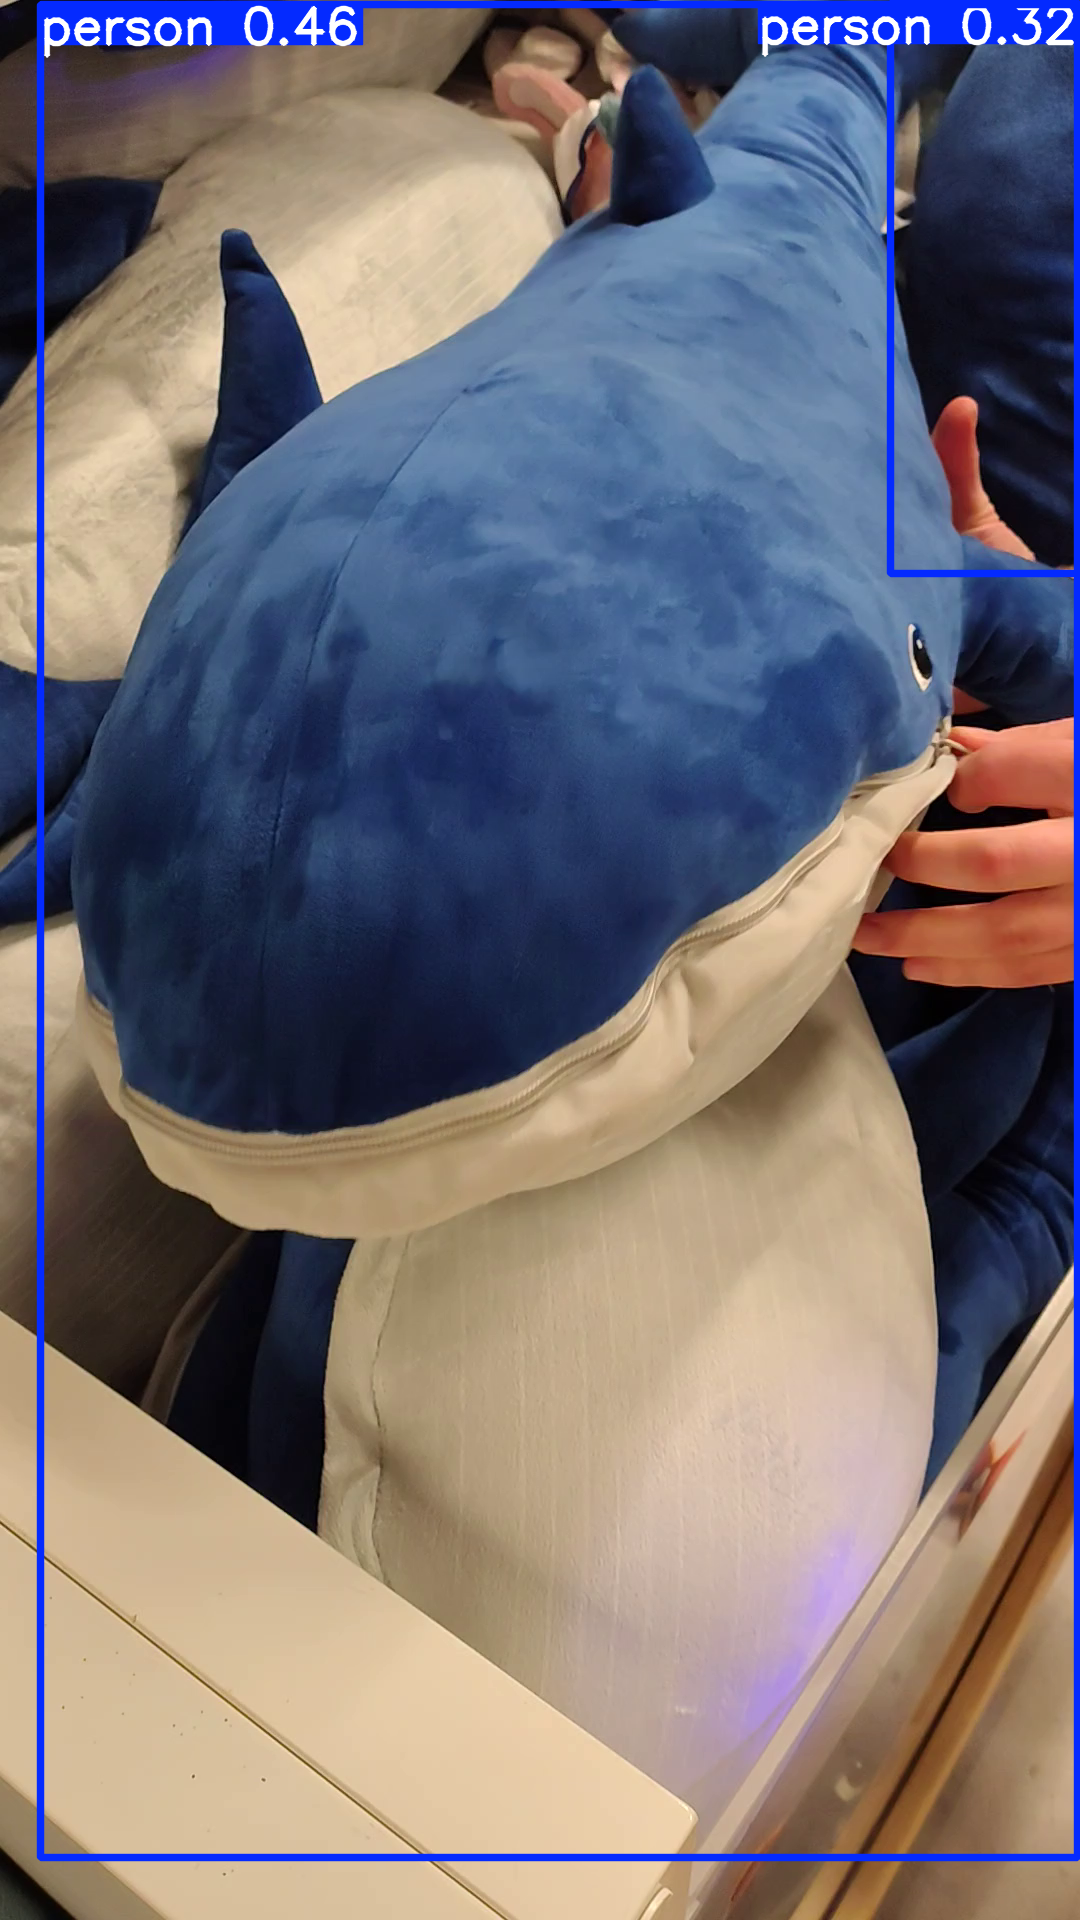

In [ ]:
# https://docs.ultralytics.com/reference/engine/results/
# results is a list for each image, for a video this corresponds to the number of frames in the video.
# For a single image it will be length 1
print(f"{len(results)} results ") # how many images input
result = results[0] # look at first frame only
boxes = result.boxes  # Boxes object for bounding box outputs
for box in boxes:
    cls = box.cls[0]
    class_name = result.names[int(cls)]
    height = box.xywh[0][3]
    print(f"Class: {class_name}, Confidence: {box.conf[0]}, Height: {height} pixels")

result.show()  # display to screen
# result.save(filename="result.jpg")  # save to disk